Мета проєкту — оцінити результативність кампаній, визначити найприбутковіші та найменш ефективні напрямки, проаналізувати динаміку витрат і ROMI, а також підготувати практичні рекомендації щодо оптимізації рекламного бюджету.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('facebook_ads_data (2.0).csv')
df.head()

,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
0,2022-11-05,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
1,2022-11-01,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
2,2022-10-31,Expansion,227.45,6054,58,191.87,3.92,37.57,0.009580,0.843570
3,2022-10-30,Expansion,335.91,27562,69,472.61,4.87,12.19,0.002503,1.406954
4,2022-10-29,Expansion,714.03,33358,115,680.34,6.21,21.41,0.003447,0.952817


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ad_date            1494 non-null   object 
 1   campaign_name      1494 non-null   object 
 2   total_spend        1494 non-null   float64
 3   total_impressions  1494 non-null   int64  
 4   total_clicks       1494 non-null   int64  
 5   total_value        1494 non-null   float64
 6   cpc                1443 non-null   float64
 7   cpm                1462 non-null   float64
 8   ctr                1462 non-null   float64
 9   romi               1462 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 116.8+ KB


In [4]:
df.describe()

,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
count,1494.000000,1494.000000,1494.000000,1494.000000,1443.000000,1462.000000,1462.000000,1462.000000
mean,131.035964,34190.182062,318.840696,165.457450,0.814712,5.085677,0.011947,1.326322
std,214.968986,44433.507387,485.663099,274.764573,1.705224,8.107076,0.013192,0.343012
min,0.000000,0.000000,0.000000,0.000000,0.010000,0.050000,0.000000,0.751445
25%,18.047500,8377.000000,62.250000,24.350000,0.170000,1.500000,0.004462,1.067832
50%,48.515000,15983.000000,148.000000,65.460000,0.350000,2.775000,0.007845,1.299482
75%,161.790000,45849.750000,371.750000,196.595000,0.765000,5.275000,0.015005,1.527423
max,2035.490000,456481.000000,6199.000000,2562.600000,24.790000,114.150000,0.159223,2.486911


In [5]:
df.isna().sum()

ad_date               0
campaign_name         0
total_spend           0
total_impressions     0
total_clicks          0
total_value           0
cpc                  51
cpm                  32
ctr                  32
romi                 32
dtype: int64

In [6]:
#переведемо тип стовпчика 'ad_date' в datetime (хоча в ДЗ є примітка на цю тему, мені спокійніше, коли дата є датою, а не текстовим обʼєктом)
df['ad_date'] = pd.to_datetime(df['ad_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ad_date            1494 non-null   datetime64[ns]
 1   campaign_name      1494 non-null   object        
 2   total_spend        1494 non-null   float64       
 3   total_impressions  1494 non-null   int64         
 4   total_clicks       1494 non-null   int64         
 5   total_value        1494 non-null   float64       
 6   cpc                1443 non-null   float64       
 7   cpm                1462 non-null   float64       
 8   ctr                1462 non-null   float64       
 9   romi               1462 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 116.8+ KB


In [7]:
# відфільтруємо дані, залишимо рядки тільки за 2021 рік
df_2021 = df[(df['ad_date'] >= '2021-01-01') & (df['ad_date'] <= '2021-12-31')].copy()

df_2021.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1167 entries, 274 to 1440
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ad_date            1167 non-null   datetime64[ns]
 1   campaign_name      1167 non-null   object        
 2   total_spend        1167 non-null   float64       
 3   total_impressions  1167 non-null   int64         
 4   total_clicks       1167 non-null   int64         
 5   total_value        1167 non-null   float64       
 6   cpc                1135 non-null   float64       
 7   cpm                1154 non-null   float64       
 8   ctr                1154 non-null   float64       
 9   romi               1154 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 100.3+ KB


In [8]:
# згрупуємо отримані дані за 2021 рік, підбиваючи суми витрат та доходів по дням;

daily_stats = df_2021.groupby('ad_date', as_index=False).agg({
    'total_spend': 'sum',
    'total_value': 'sum'})

# розрахуємо щоденне ROMI, як частку від витрат на рекламу на дохід від реклами, виключаючи значення 'total_spend' = 0
# (для того, щоб запобігти "діленню на 0", та на той випадок, якщо ми нічого не витрачали - ми не маємо розраховувати ефективність заходу)

daily_stats['romi'] = np.where(
    daily_stats['total_spend'] > 0,
    daily_stats['total_value'] / daily_stats['total_spend'],
    np.nan)


In [9]:
# розрахуємо рухоме середніх витрат та ROMI за 7 днів

daily_stats['spend_rolling_7'] = daily_stats['total_spend'].rolling(7, min_periods=1).mean() 
daily_stats['romi_rolling_7'] = daily_stats['romi'].rolling(7, min_periods=1).mean() 

daily_stats.head()

,ad_date,total_spend,total_value,romi,spend_rolling_7,romi_rolling_7
0,2021-01-01,0.39,0.59,1.512821,0.390000,1.512821
1,2021-01-02,7.74,6.90,0.891473,4.065000,1.202147
2,2021-01-04,70.06,68.47,0.977305,26.063333,1.127200
3,2021-01-05,81.15,61.68,0.760074,39.835000,1.035418
4,2021-01-06,142.77,145.97,1.022414,60.422000,1.032817


In [10]:
# роблю заготовку для майбутніх графіків

# кольорова гама графіків
bg = '#F8F5F0'       
text = '#2B2B2B'     
grid = '#E6E1D9'
green = '#0F5C4D'   
gold = '#C6A96B'     
soft = '#D8CFC2'     
red = '#7A2E3A'      


# кольорова гама кампаній
campaign_palette = {
    'Expansion': '#0F5C4D',
    'Lookalike': '#355070',
    'Trendy': '#C6A96B',
    'Promos': '#7A2E3A',
    'Electronics': '#2F3E46',
    'Brand': '#6C757D',
    'Wholesale': '#8D99AE',
    'Hobbies': '#A8DADC',
    'New items': '#E9C46A',
    'Crazy discounts': '#E63946',
    'Discounts': '#B5838D'}

# саме оформлення графіків по палітрі
sns.set_theme(style='whitegrid')

plt.rcParams.update({
    'figure.facecolor': bg,
    'axes.facecolor': bg,
    'axes.edgecolor': grid,
    'axes.labelcolor': text,
    'xtick.color': text,
    'ytick.color': text,
    'text.color': text,
    'axes.titleweight': 'bold',
    'axes.titlesize': 16,
    'axes.labelsize': 12})

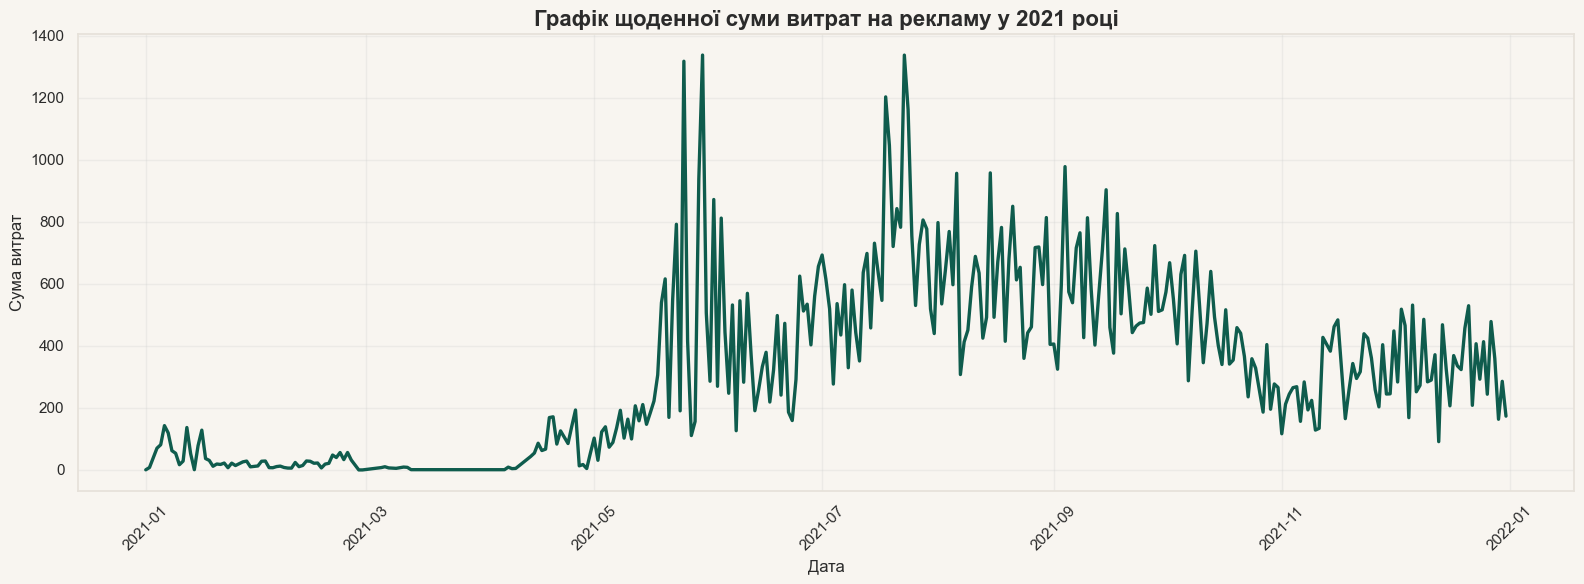

In [11]:
# побудуємо графік щоденних витрат

plt.figure(figsize=(16, 6))

plt.plot(
    daily_stats['ad_date'],
    daily_stats['total_spend'],
    color=green,
    linewidth=2.4)

plt.title('Графік щоденної суми витрат на рекламу у 2021 році')
plt.xlabel('Дата')
plt.ylabel('Сума витрат')
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

З графіку щоденних витрат видно, **скільки грошей було витрачено кожного дня**.  
В нашому випадку витрати на рекламу протягом року розподілені **нерівномірно**: 
є спокійні періоди на початку року та скачкоподібні, починаючи з кінця весни 
(скоріш за все це обумовлено сезонністю пропозицій та специфічністю самих кампаній).
Присутні нульові витрати за день та максимальні витрати в липні та серпні в районі 1350 (якихось умовних одиниці, бо в дата-сеті не зазначена валюта)

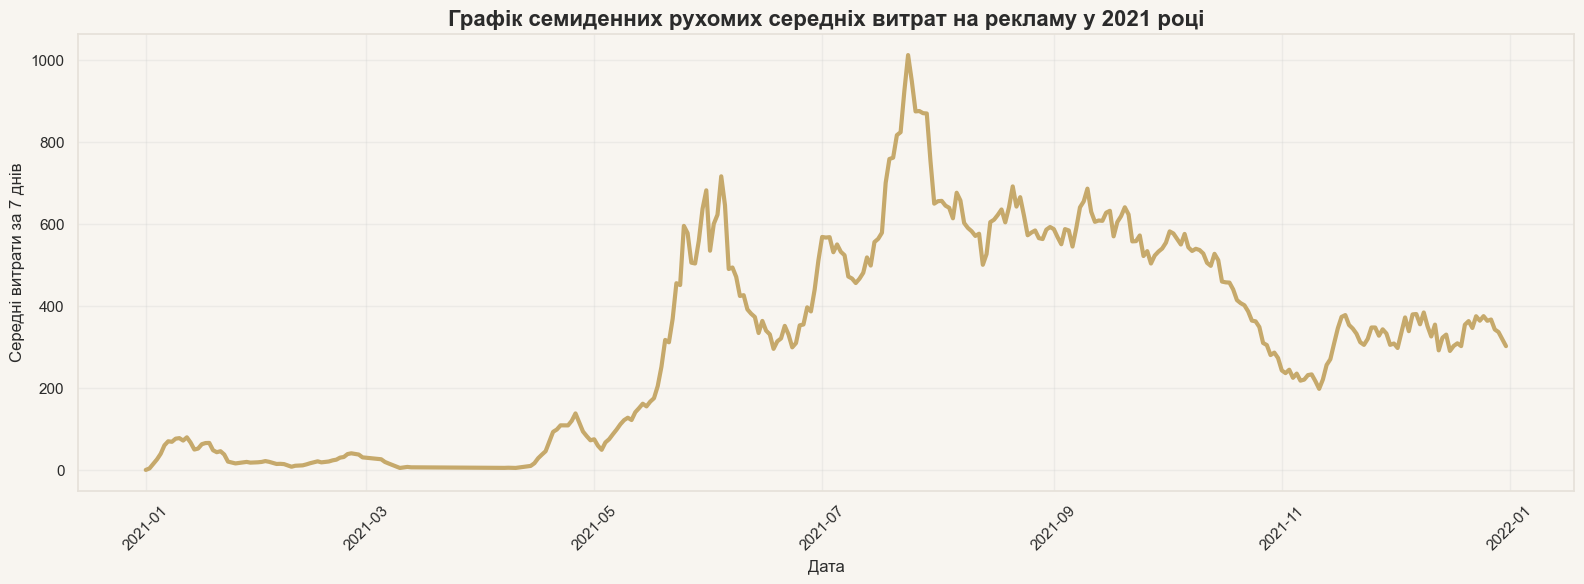

In [12]:
# побудуємо графік рухомих витрат за 7 днів

plt.figure(figsize=(16, 6))

plt.plot(
    daily_stats['ad_date'],
    daily_stats['spend_rolling_7'],
    color=gold,
    linewidth=3)

plt.title('Графік семиденних рухомих середніх витрат на рекламу у 2021 році')
plt.xlabel('Дата')
plt.ylabel('Середні витрати за 7 днів')
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Графік рухомих витрат допомагає **визначити загальну тенденцію** витрат та допомагає краще оцінити **загальну динаміку** бюджета реклами.

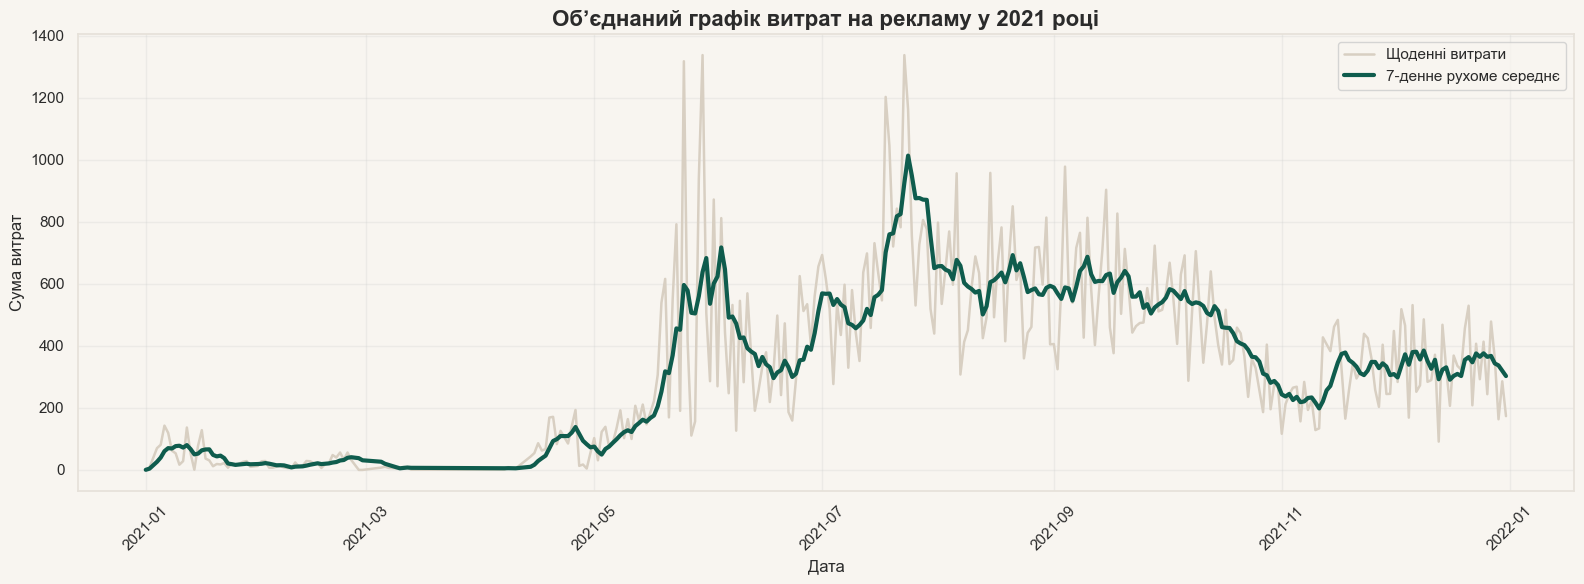

In [13]:
# для більшої наглядності обʼєднаємо ці 2 графіки в одному

plt.figure(figsize=(16, 6))

plt.plot(
    daily_stats['ad_date'],
    daily_stats['total_spend'],
    color=soft,
    linewidth=1.8,
    label='Щоденні витрати')

plt.plot(
    daily_stats['ad_date'],
    daily_stats['spend_rolling_7'],
    color=green,
    linewidth=3,
    label='7-денне рухоме середнє')

plt.title('Обʼєднаний графік витрат на рекламу у 2021 році')
plt.xlabel('Дата')
plt.ylabel('Сума витрат')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Тут ми одночасно можемо спостерігати і фактичні денні витрати, і середній рівень витрат за 7 днів:  
**світла лінія** - це реальні витрати по днях;  
**зелена** - більш згладжена лінія - загальний тренд витрат.  
Порівнюючи щоденні фактичні показники і рухомі, очевидно, що з кінця травня - початку червня рекламна активність збільшилась, в серпні сягнула свого піку, восени пішла на спад та взимку частково відновилась.

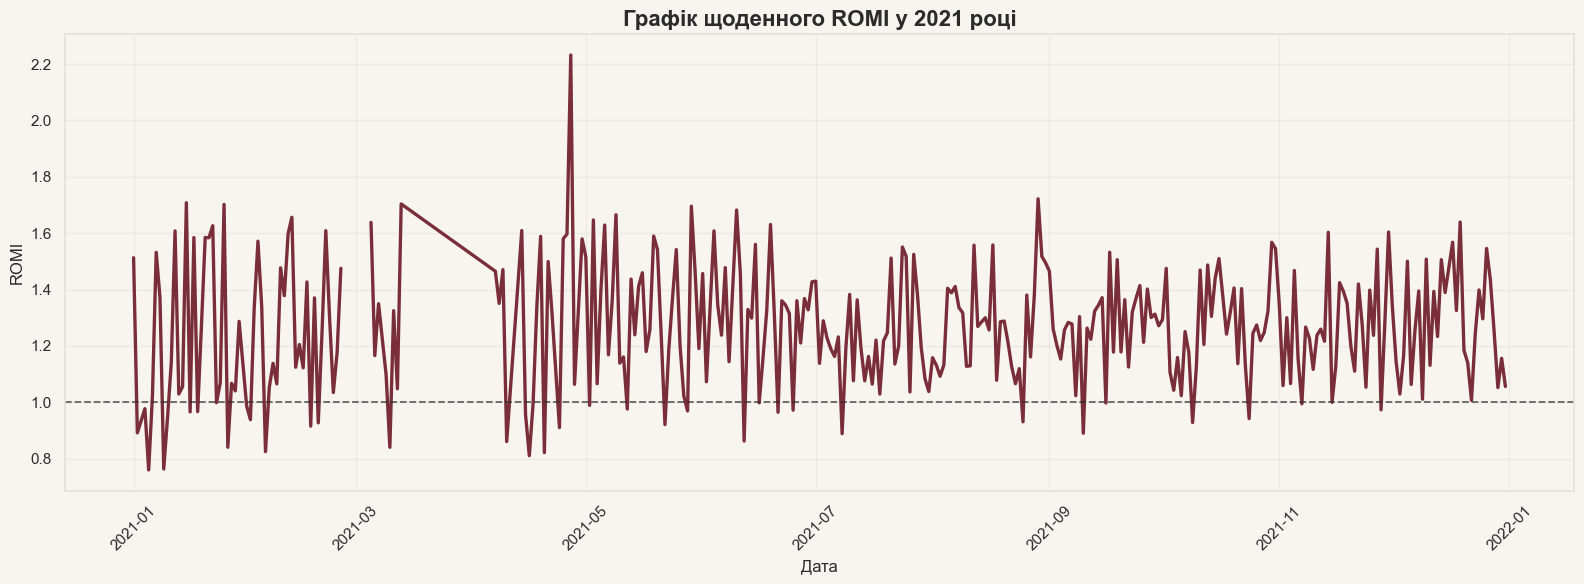

In [14]:
# побудуємо графік щоденних ROMI

plt.figure(figsize=(16, 6))

plt.plot(
    daily_stats['ad_date'],
    daily_stats['romi'],
    color=red,
    linewidth=2.4)

plt.axhline(
    1,
    color=text,
    linestyle='--',
    linewidth=1.3,
    alpha=0.7)

plt.title('Графік щоденного ROMI у 2021 році')
plt.xlabel('Дата')
plt.ylabel('ROMI')
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Графік щоденного ROMI показує, як змінювалась ефективність реклами за період 2021 року.  
Лінія ROMI **вище позначки 1** - означає, що реклама принесла прибуток компанії;  
Лінія ROMI **на рівні позначки 1** - означає, що рекламні вкладення окупилися (без прибутку);  
Лінія ROMI **нижче позначки 1** - означає, що реклама була слабка, витрати не виправдались та компанія втратила гроші.  
В нашому випадку, на графіку видно, що в своїй більшості присутні позитивні (ефективні) періоди, що приносили користь компанії, проте існуює частка негативних показників, що означають слабку окупаємість за конкретний день.  
**Мінімальний ROMI за день** становить приблизно **0.75** у січні, максимальний - близько **2.23** у квітні.

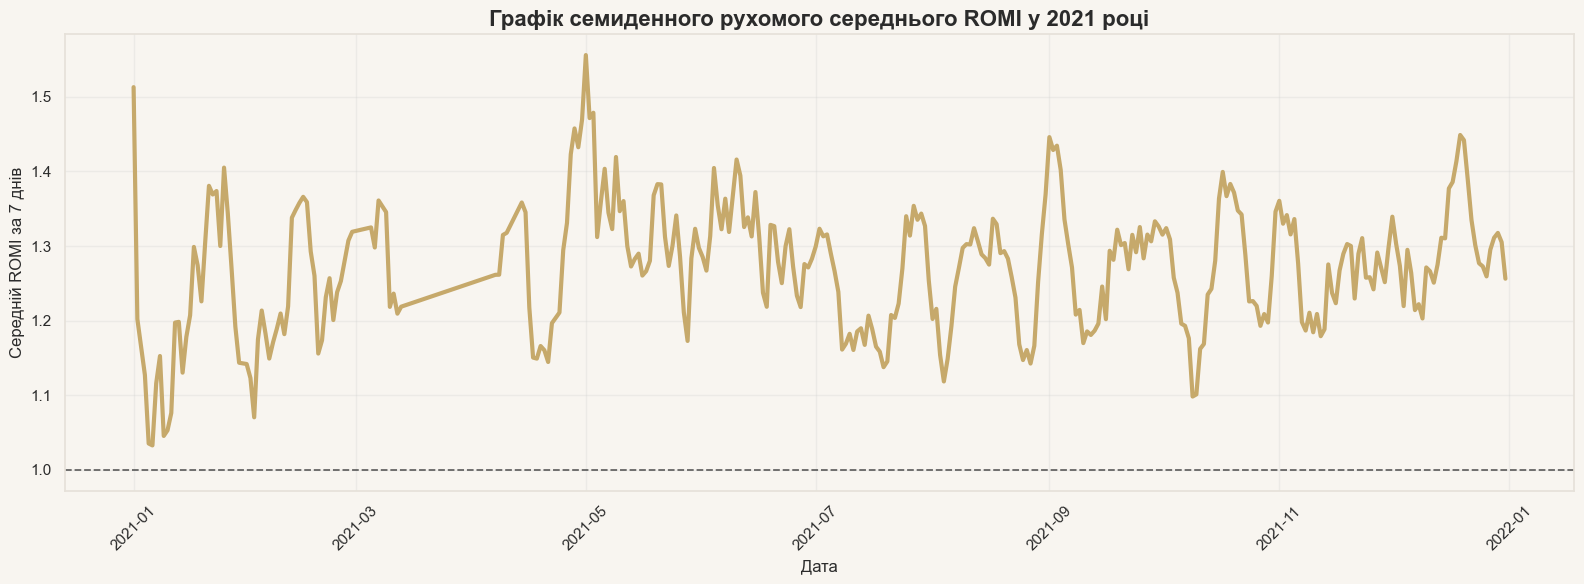

In [15]:
# побудуємо графік рухомих ROMI за 7 днів

plt.figure(figsize=(16, 6))

plt.plot(
    daily_stats['ad_date'],
    daily_stats['romi_rolling_7'],
    color=gold,
    linewidth=3)

plt.axhline(
    1,
    color=text,
    linestyle='--',
    linewidth=1.3,
    alpha=0.7)

plt.title('Графік семиденного рухомого середнього ROMI у 2021 році')
plt.xlabel('Дата')
plt.ylabel('Середній ROMI за 7 днів')
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

На графіку 7-ми денного рухомого середнього ROMI можна вже відслідкувати більш стійку динаміку ефективності.  
Хоча тененція ефективністі реклами змінювалася нерівномірно, добрим знаком є те, що **за весь період лінія ROMI знаходиться вище позначки 1**. Тобто в середньому реклама окуповувалась і приносила прибуток компанії.

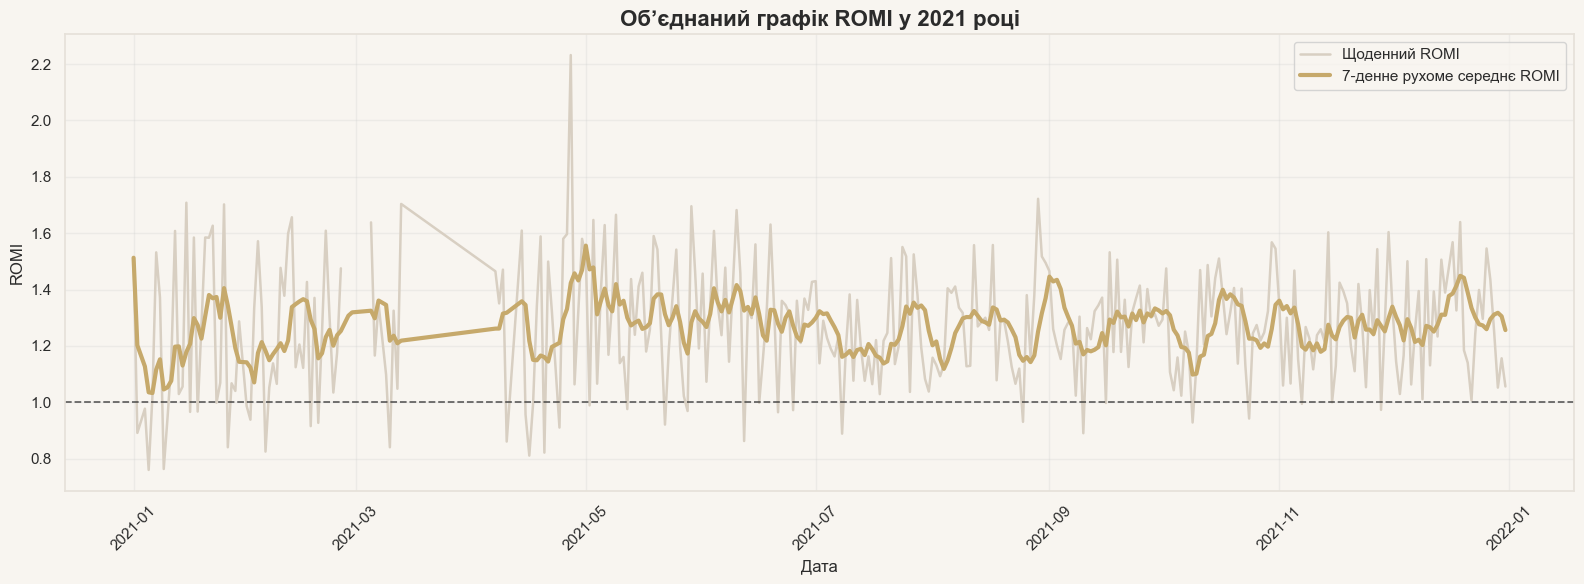

In [16]:
# також зробимо суміщений графік по ROMI для більшої наглядності

plt.figure(figsize=(16, 6))

plt.plot(
    daily_stats['ad_date'],
    daily_stats['romi'],
    color=soft,
    linewidth=1.8,
    label='Щоденний ROMI')

plt.plot(
    daily_stats['ad_date'],
    daily_stats['romi_rolling_7'],
    color=gold,
    linewidth=3,
    label='7-денне рухоме середнє ROMI')

plt.axhline(
    1,
    color=text,
    linestyle='--',
    linewidth=1.3,
    alpha=0.7)

plt.title('Обʼєднаний графік ROMI у 2021 році')
plt.xlabel('Дата')
plt.ylabel('ROMI')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Як і в попередньому випадку з витратами, тут ми бачимо фактичне щоденне та 7-ми денне рухоме середнє ROMI. На графіку ми можемо спостерігати та порівняти щоденні скачки та загальну, більш плавну тенденцію ефективності реклами.

In [17]:
# за тим самим принципом, виконаємо групування за кампаніями (але вже за всією таблицею)

campaign_stats = df.groupby('campaign_name', as_index=False).agg({
    'total_spend': 'sum',
    'total_value': 'sum'
})

campaign_stats['romi'] = np.where(
    campaign_stats['total_spend'] > 0,
    campaign_stats['total_value'] / campaign_stats['total_spend'],
    np.nan
)

# та відсортуємо отримані дані за спаданням

campaign_spend_sorted = campaign_stats.sort_values('total_spend', ascending=False)
campaign_romi_sorted = campaign_stats.sort_values('romi', ascending=False)

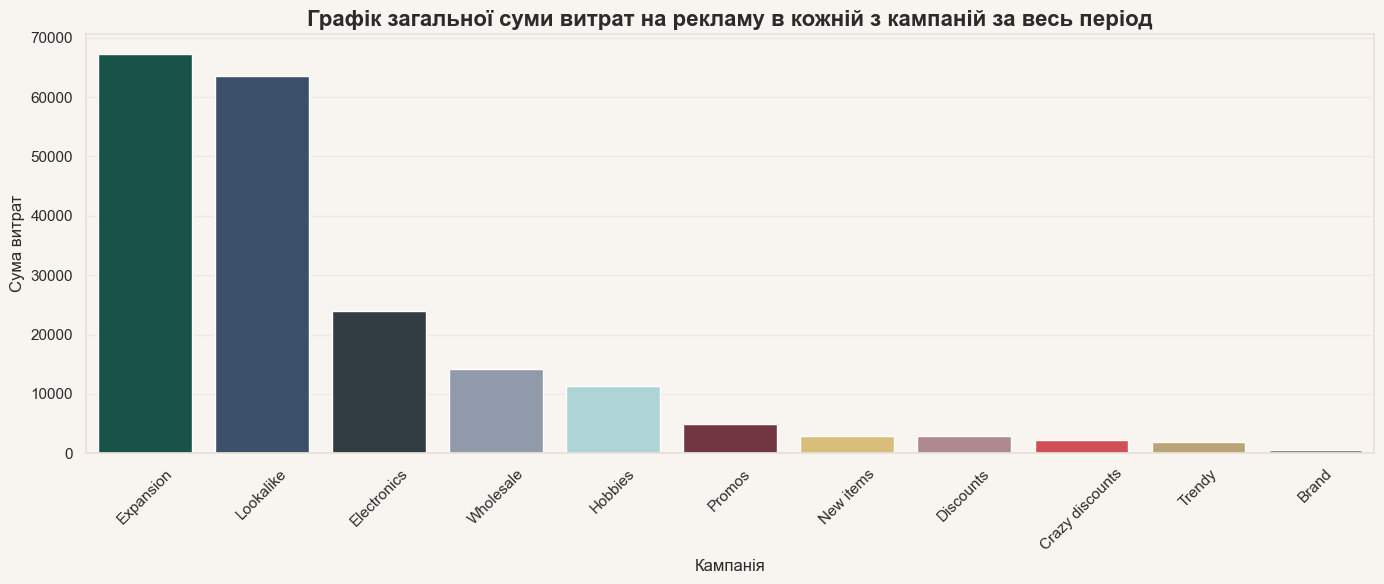

In [18]:
# побудуємо графік витрат за кампаніями

plt.figure(figsize=(14, 6))

sns.barplot(
    data=campaign_spend_sorted,
    x='campaign_name',
    y='total_spend',
    hue='campaign_name',
    palette=campaign_palette,
    dodge=False
)

plt.title('Графік загальної суми витрат на рекламу в кожній з кампаній за весь період')
plt.xlabel('Кампанія')
plt.ylabel('Сума витрат')
plt.xticks(rotation=45)
plt.legend([], [], frameon=False)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

Графік демонструє, що компанія найбільше вкладалася в кампанії:  
**"Expansion"** - близько 67000 у.о. та  
**"Lookalike"** - близько 63000 у.о.

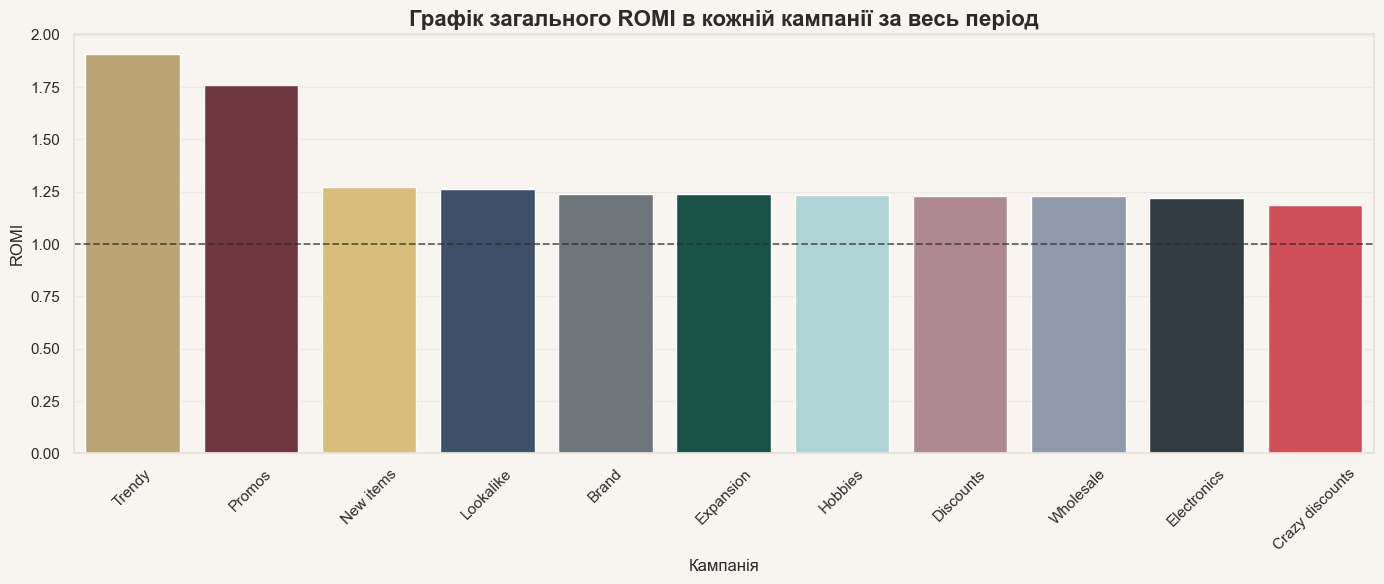

In [19]:
# та графік ROMI за кампаніями

plt.figure(figsize=(14, 6))

sns.barplot(
    data=campaign_romi_sorted,
    x='campaign_name',
    y='romi',
    hue='campaign_name',
    palette=campaign_palette,
    dodge=False)

plt.axhline(
    1,
    color=text,
    linestyle='--',
    linewidth=1.3,
    alpha=0.7)

plt.title('Графік загального ROMI в кожній кампанії за весь період')
plt.xlabel('Кампанія')
plt.ylabel('ROMI')
plt.xticks(rotation=45)
plt.legend([], [], frameon=False)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


З попереднього графіка ми знаємо, що компанія робила ставку та вкладала гроші в кампанії "Expantion" та "Lookalike", проте **найбільшу користь по рекламі** принесли кампанії **"Trendy"**  та **"Promos"**, які мали в десятки разів **менший бюджет**.

*Ця частина просто для аналізу і запитання (нижче в макрдауні):*

In [20]:
selected_camp = ['Expansion', 'Lookalike', 'Trendy', 'Promos']

df_selected = df[df['campaign_name'].isin(selected_camp)]

camp_result = df_selected.groupby('campaign_name', as_index=False).agg({
    'total_spend': 'sum',
    'total_value': 'sum'
})


camp_result['profit'] = camp_result['total_value'] - camp_result['total_spend']

camp_result['romi'] = camp_result['total_value'] / camp_result['total_spend']

camp_result = camp_result.sort_values('total_value', ascending=False)

camp_result

,campaign_name,total_spend,total_value,profit,romi
0,Expansion,67212.82,83288.66,16075.84,1.239178
1,Lookalike,63631.09,80234.70,16603.61,1.260935
2,Promos,4993.84,8793.77,3799.93,1.760923
3,Trendy,1992.31,3798.90,1806.59,1.906782


*Запитання: Що приорітетніше для компанії - витрачені та "повернуті" **гроші** (Expansion та Lookalike, хоча Loolalike по профіту на 1-му місці) чи **ефективність** кампанії при невеликому бюджеті (Trendy та Promos), а отже і прибуток відповідний (хоча, якщо в них вкладатися - не має гарантії, що вони поводитимуться аналогічно на великих масштабах)?*

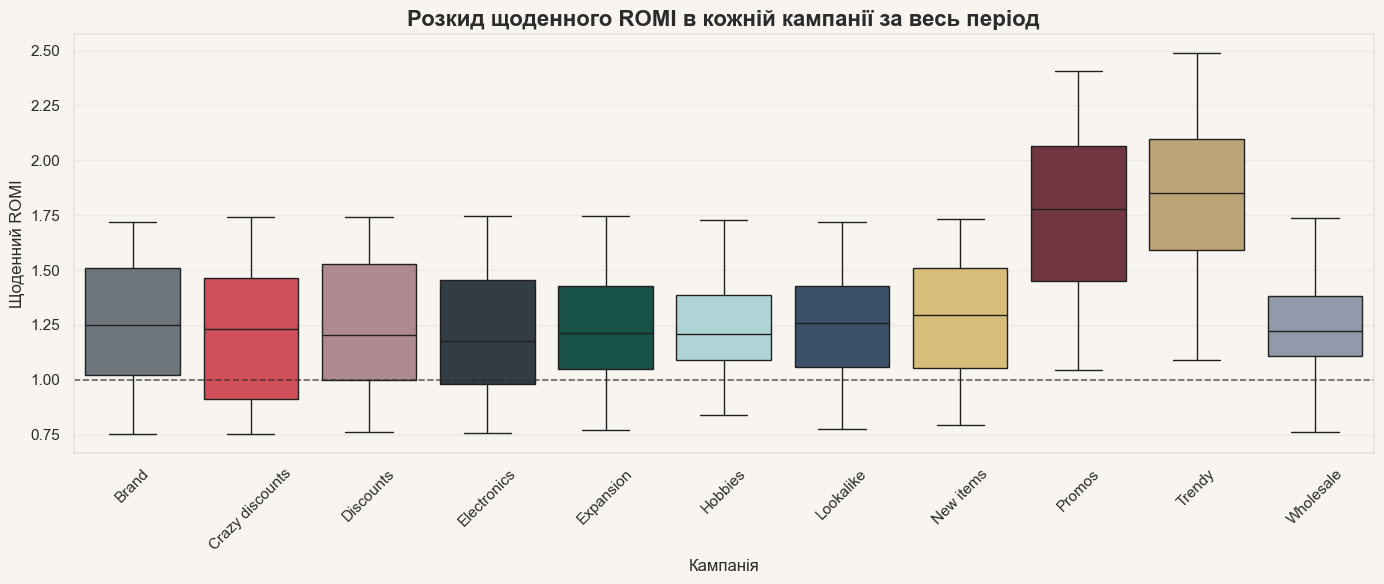

In [21]:
# будуємо box plot - щоденний ROMI за кампаніями

campaign_day = df.groupby(['campaign_name', 'ad_date'], as_index=False).agg({
    'total_spend': 'sum',
    'total_value': 'sum'
})

campaign_day['romi'] = np.where(
    campaign_day['total_spend'] > 0,
    campaign_day['total_value'] / campaign_day['total_spend'],
    np.nan
)

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=campaign_day,
    x='campaign_name',
    y='romi',
    hue='campaign_name',
    palette=campaign_palette,
    dodge=False
)

plt.axhline(
    1,
    color=text,
    linestyle='--',
    linewidth=1.2,
    alpha=0.7
)

plt.title('Розкид щоденного ROMI в кожній кампанії за весь період')
plt.xlabel('Кампанія')
plt.ylabel('Щоденний ROMI')
plt.xticks(rotation=45)
plt.legend([], [], frameon=False)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

Box plot нам показує **розкид щоденного ROMI всередині кожної кампанії**, тобто наскільки стабільно чи нестабільно кампанія видає ROMI по дням.  
**Лінія в середині коробки** - це медіана ROMI,  
**сама коробка** - діапазон значень ROMI,  
**"вуса"** - розкид,  
**лінія позначки 1** - границя окупності.

Дуже гарним є показник, що **медіана ROMI для всіх кампаній вище позначки 1**.
Кампанії **Brand, Crazy discounts, Discounts, Electronics, Expansion, Lookalike, New items та Wholesale** мають приблизно однаковий розкид **від 0.75 до 1.75**.  
Кампанія **Hobbies** має розкид **від 0.85 до 1.75**,  
Кампанія **Promos** має розкид **від 1.05 до 2.45**,  
Кампанія **Trendy** має розкид **від 1.1 до 2.50**.  

Якщо аналізувати **висоту коробки** (діапазон значень ROMI) - **найстабільнішими** себе показують кампанії **Wholesale, Hobbies, Lookalike та Expansion**, при цьому вони мають медіану в діапазоні 1.2-1.25, що вказує на те, що це **не найбільш прибуткові** кампанії (та і "вуса" опускають нижче позначки 1);  
**найнестабільніші кампанії - Promos, Crazy discounts, Discounts та Trendy**, але при цьому **Promos та Trendy** мають коливання в більш **високому діапазоні** та мають високу медіану, кампанії **Crazy discounts, Discounts та Electronics** знаходяться біля та **нижче позначки 1**, а значить реклама була слабкою, що в майбутньому може стати причиною втрати коштів компанії.



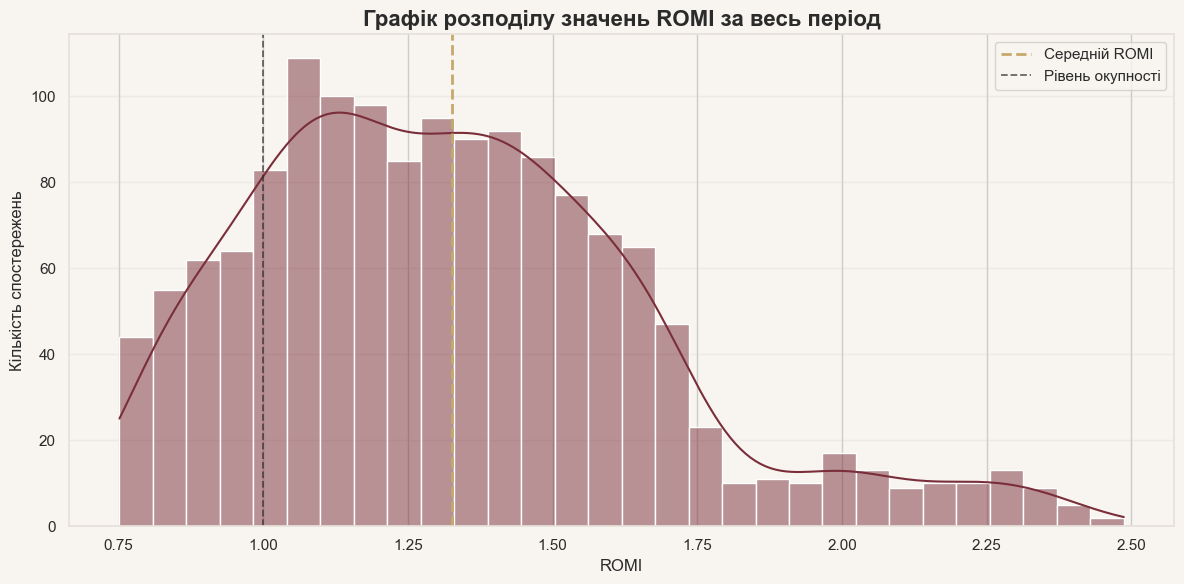

In [22]:
# побудуємо гістаграмму ROMI

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x='romi',
    bins=30,
    kde=True,
    color=red)

plt.axvline(
    df['romi'].mean(),
    color=gold,
    linestyle='--',
    linewidth=2,
    label='Середній ROMI')

plt.axvline(
    1,
    color=text,
    linestyle='--',
    linewidth=1.3,
    alpha=0.7,
    label='Рівень окупності')

plt.title('Графік розподілу значень ROMI за весь період')
plt.xlabel('ROMI')
plt.ylabel('Кількість спостережень')
plt.legend()
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

Гістограмма показує які **значення ROMI зустрічаються найчастіше**.  
Основна частина найбільш поширених значень розташовується **в діапазоні від 1 до 1.5**, викиди та екстремальні значення зустрічаються значно рідше.  
Загалом це свідчить про достатньо стабільну та позитивну динаміку заходів.

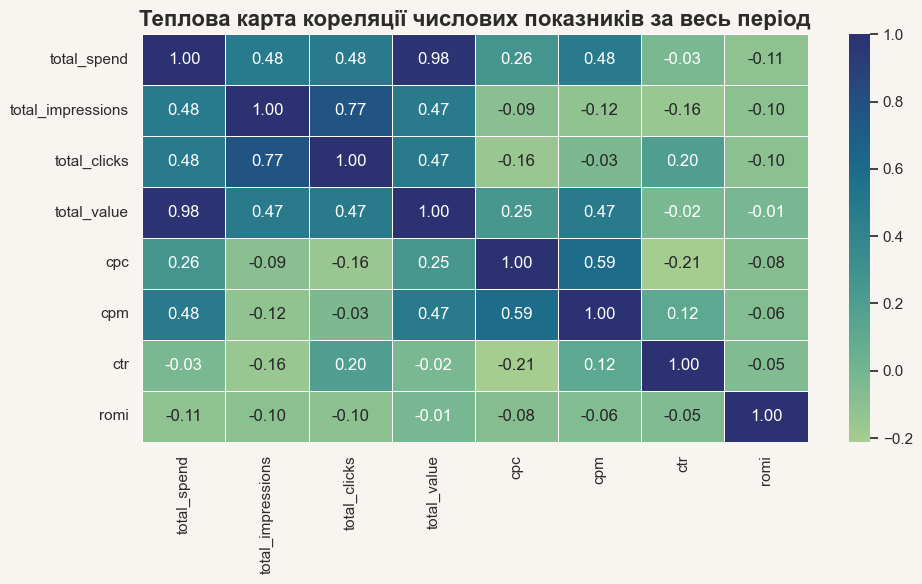

In [23]:
# будуємо теплову карту корреляції, обираючи усі числові стовпці

numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='crest',
    linewidths=0.5)

plt.title('Теплова карта кореляції числових показників за весь період')
plt.tight_layout()
plt.show()

Теплова карта показує нам звʼзки між числовими показниками.  
**Найбільша кореляція 0.98** в нашому випадку - між **total_spend та total_value**, тобто, чим більше витрати - тим більше отримуємо доходу.  
Також логічний звʼязок між **total_impressions та total_clicks (0.77)**: чим більше показів, там більше переходів за посиланням.  
**Не має звʼязку між total_value та ROMI (-0.01)**, тобто високий дохід не приводить автоматично до високої ефективності.  
**Мінімальний звʼязок** тут між **cpc та ctr (-0.21)**, тобто, чим дорожчий клік - тим гірше клікабельність. (*хоча тут з якої сторони дивитися: чим гірша клікабельність - тим дорожче коштує клік*)

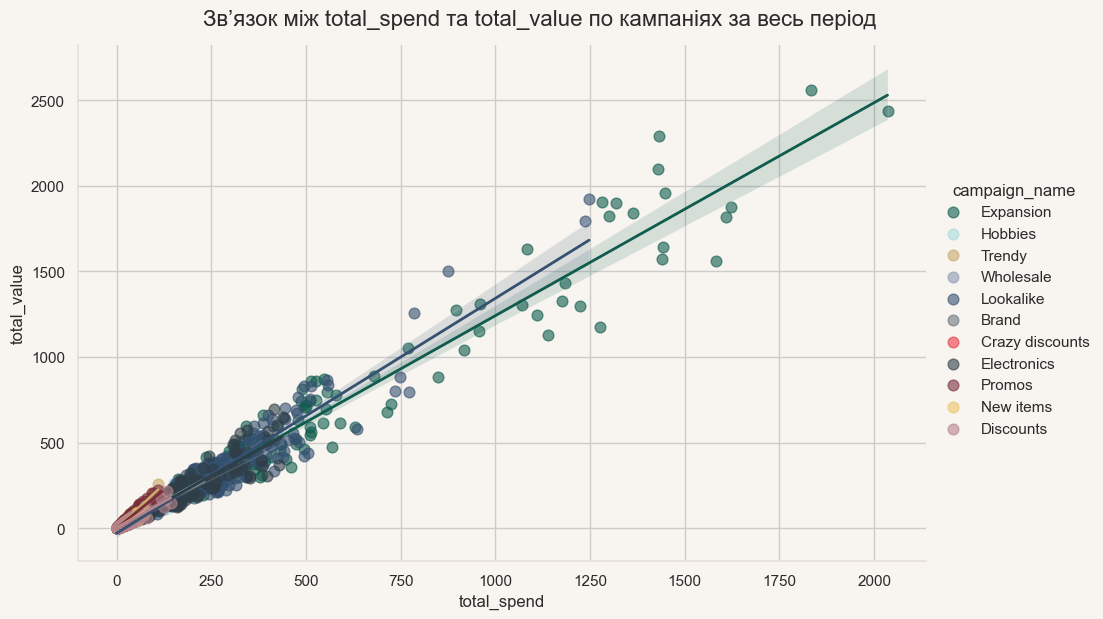

In [24]:
# будуємо лінійну регресію

g = sns.lmplot(
    data=df,
    x='total_spend',
    y='total_value',
    hue='campaign_name',      
    palette=campaign_palette, 
    height=6,
    aspect=1.6,
    scatter_kws={'alpha': 0.6, 's': 60},
    line_kws={'linewidth': 2})

g.fig.suptitle(
    'Зв’язок між total_spend та total_value по кампаніях за весь період',
    y=1.03,
    fontsize=16)

plt.show()

**Точкова діаграма** з лінією регресії демонструє **позитивну залежність між total_spend та total_value** - якщо зростають витрати, цінність також зростає.  
Це ще раз підтверджує кореляцію між total_spend та total_value з попереднього пункта.  
Розбіжність точок відносно лінійної регресії свідчить про те, що **різні кампанії** при тому самому бюджеті можуть приносити **різний результат**.

**Фінальні бізнес-рекомендації:**  
*1. якщо збільшити бюджет на "Expansion" та "Lookalike", скоріше за все total_value також збільшиться (сильний звʼязок total_spend та total_value);*  
*2. звернути увагу на кампанії "Trendy" та "Promos" - в них найвищий ROMI, тобто це найефективніші кампанії, проте маштабувати їх потрібно поступово та постійно моніторити тенденцію при зростанні обсягів.*